# Download data from Copernicus Earth Observation Data Centre (EODC)
This code snippet provides an example of accessing and downloading data from the European Union's Copernicus platform (for example, Sentinel-2 data) using the pystac and odc-stac libraries for accessing STAC catalogs through Python (see the docs for [pystac](https://pystac.readthedocs.io/en/stable/) and [odc-stac](https://odc-stac.readthedocs.io/en/latest/)).

You will first need to register for (free) Copernicus data access: https://documentation.dataspace.copernicus.eu/Registration.html.

This example borrows code from the EODC GFM tutorial: https://github.com/eodcgmbh/eodc-examples/blob/main/demos/GFM/gfm_maximum_flood_extent_local.ipynb

You can browse the datasets available through the EODC here: https://services.eodc.eu/browser/#/?.language=en

In this example we will use the Global Flood Monitoring dataset, a water extent product derived from Sentinel-1 imagery. You could also use this same workflow to obtain multispectral Sentinel-2 imagery for example.

## Setup

In [32]:
# Install earthaccess
!pip install odc-stac pystac_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [odc-stac]1/3 [odc-loader]


In [33]:
import pyproj
from pystac_client import Client
from odc import stac as odc_stac
import rioxarray as riox
import xarray as xr
from datetime import datetime
from shapely.geometry import box
from pathlib import Path

## Define search query parameters

Here is where you'll **update using your own search parameters:**
* The sensor / product name: known as the **collection**
* The bands you want from the collection
* The region: here defined using a **bounding box**
* The time period: here defined using a **start and end date** in datetime objects
* Additional metadata: Coordinate Reference System, no data value, maximum number of items to return

In [67]:
# Define the API URL and STAC collection ID
api_url = "https://stac.eodc.eu/api/v1"
collection_id = "GFM"

# Define desired bands
bands = ["ensemble_water_extent", "exclusion_mask"]

# Define project CRS
projectCRS = 'epsg:4326'

# Define the time range for the search
time_range = (datetime(2019, 5, 3), datetime(2019, 5, 4))

# Define region of interest using bounding box geometry
aoi = box(-97.7, 42.8, -97.5, 43.0)

# Define target no data value
nodataval=-9999

# Define the max number of items to return
max_items=100

## Search the EODC STAC catalog

In [68]:
# Open the STAC catalog using the specified API URL
eodc_catalog = Client.open(api_url)
eodc_catalog

<Client id=stac-fastapi>

In [69]:
# Perform a search in the catalog with the specified parameters
search = eodc_catalog.search(
    max_items=max_items,             # Maximum number of items to return
    collections=collection_id,  # The collection to search within
    intersects=aoi,             # The area of interest
    datetime=time_range         # The time range for the search
)

# Collect the found items into an item collection
items = search.item_collection()
print(f"Found {len(items)} items for the search query.")

items

Found 2 items for the search query.


In [70]:
# Search for data
# This example retries data from ICESAT
results = earthaccess.search_data(
    short_name='ATL06',
    bounding_box=(-10, 20, 10, 50),
    temporal=("1999-02", "2019-03"),
    count=10 # Limits to max number of query results
)

# Briefly show the search results
print(f'Search returned {len(results)} results')
print('\nShowing the first result:\n', results[0])

NameError: name 'earthaccess' is not defined

In [ ]:
# Look at the first result from our search
result = results[0]

# Notice the type - earthaccess.results.DataGranule
# Read more about data granules: https://www.earthdata.nasa.gov/news/feature-articles/data-tool-focus-earthdata-search
print(type(result))

# It comes with interactive clickable elements, including a link to the data file
result

In [ ]:
# Inspect the first item - what does it contain?
# In particular look under properties
items[0]

In [71]:
print(items[0].properties)

# For example you can check the timestamp of the product image
print('\n', items[0].properties['datetime'])

{'gsd': 20, 'created': '2024-11-13T16:14:11.748626+00:00', 'datetime': '2019-05-03T00:30:11Z', 'Equi7Tile': 'NA020M_E081N036T3', 'blocksize': {'x': 512, 'y': 512}, 'proj:bbox': [8100000, 3600000, 8400000, 3900000], 'proj:wkt2': 'PROJCS["Azimuthal_Equidistant",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AUTHORITY["EPSG","4326"]],PROJECTION["Azimuthal_Equidistant"],PARAMETER["false_easting",8264722.17686],PARAMETER["false_northing",4867518.35323],PARAMETER["longitude_of_center",-97.5],PARAMETER["latitude_of_center",52.0],UNIT["metre",1,AUTHORITY["EPSG","9001"]]]', 'proj:shape': [15000, 15000], 'constellation': 'sentinel-1', 'flood_members': {'DLR': True, 'TUW': True, 'LIST': True}, 'proj:geometry': {'type': 'Polygon', 'coordinates': [[[8100000.0, 3600000.0], [8100000.0, 3900000.0], [8400000.0, 3900000.0], [8400000.0, 3600000.0], [8100000.0, 3600000.0]]]

In [72]:
# Extract the coordinate reference system (CRS) from the first item's properties
crs = pyproj.CRS.from_wkt(items[0].properties["proj:wkt2"])
print(crs)

# Extract the resolution of the data
resolution = items[0].properties['gsd']
print('\n', resolution)

PROJCS["Azimuthal_Equidistant",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AUTHORITY["EPSG","4326"]],PROJECTION["Azimuthal_Equidistant"],PARAMETER["false_easting",8264722.17686],PARAMETER["false_northing",4867518.35323],PARAMETER["longitude_of_center",-97.5],PARAMETER["latitude_of_center",52.0],UNIT["metre",1,AUTHORITY["EPSG","9001"]]]

 20


## Open the data from EODC

Now we have returned items from our search query, we can stream the data from the STAC catalog to our machine. You will first need to specify the files from your search that you want to download.

In [73]:
# Load the data using odc_stac.load() with the specified parameters
print(f'Loading data from collection {collection_id} for bands {bands}.')
dataset = odc_stac.load(
    items, 
    bbox=aoi.bounds,   
    crs=crs,   
    bands=bands,
    resolution=resolution,  
    dtype='uint8', 
    groupby="solar_day",
    # fail_on_error=False,
)
print('Opened the data.')

Loading data from collection GFM for bands ['ensemble_water_extent', 'exclusion_mask'].
Opened the data.


In [74]:
# View the dataset
dataset

<xarray.Dataset> Size: 2MB
Dimensions:                (y: 1113, x: 823, time: 1)
Coordinates:
  * y                      (y) float64 9kB 3.867e+06 3.867e+06 ... 3.845e+06
  * x                      (x) float64 7kB 8.248e+06 8.248e+06 ... 8.265e+06
  * time                   (time) datetime64[ns] 8B 2019-05-03T00:29:46
    spatial_ref            int32 4B 0
Data variables:
    ensemble_water_extent  (time, y, x) uint8 916kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
    exclusion_mask         (time, y, x) uint8 916kB 0 0 0 0 0 0 ... 1 1 1 1 1 1

(1, 1113, 823)


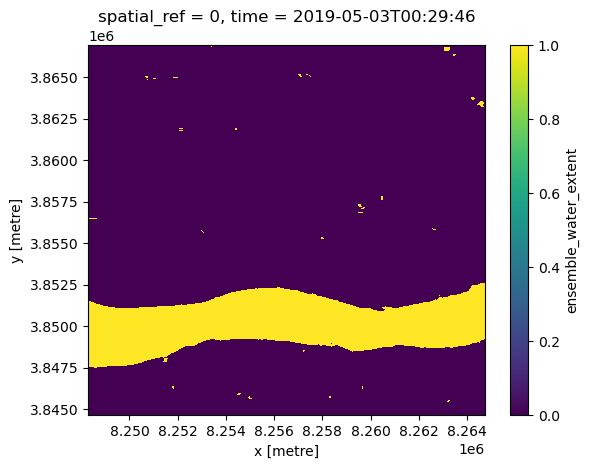

In [76]:
# Inspect the water mask data array
watermask_da = dataset['ensemble_water_extent']
print(watermask_da.shape)
watermask_da.plot(vmin=0, vmax=1)

## Data download

You could choose to download the entire dataset as a netcdf, or you can download a data array of a single variable (or stack of raster bands of the same variable) in a GeoTiff.

In [79]:
# Define path to download to
downloadPath = Path('data/downloads/EODC_GFM') # MODIFY
downloadPath.mkdir(exist_ok=True, parents=True) # Create download directory if does not already exist

In [80]:
# Download the water mask data array as geotiff
watermask_da.rio.to_raster(downloadPath/'watermask_2019-05-03.tif')